# Naive Bayes — Credit Card Fraud Dataset

This notebook applies the Gaussian Naive Bayes classifier to the Credit Card Fraud dataset. The aim is to classify transactions as normal or fraudulent.

Since the dataset is highly imbalanced, the model is evaluated using Accuracy, Precision, Recall, F1-score, ROC-AUC, and confusion matrix analysis.

In [3]:
# =====================================================
# 1. IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [4]:
# =====================================================
# 2. LOAD CREDIT CARD DATASET
# =====================================================

credit = pd.read_csv("../dataset/creditcard.csv")

print("Original Credit Card Dataset Shape:", credit.shape)

display(credit.head())

Original Credit Card Dataset Shape: (16819, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# =====================================================
# 3. CREDIT CARD DATA CLEANING
# =====================================================

credit_clean = credit.copy()

original_shape = credit_clean.shape

# Remove duplicate rows
credit_clean = credit_clean.drop_duplicates()

# Remove missing values if any
credit_clean = credit_clean.dropna()

# Ensure target column is integer
credit_clean["Class"] = credit_clean["Class"].astype(int)

# Reset index
credit_clean = credit_clean.reset_index(drop=True)

print("Original Shape:", original_shape)
print("Cleaned Shape:", credit_clean.shape)

print("\nMissing Values After Cleaning:")
display(pd.DataFrame({"Missing Values": credit_clean.isnull().sum()}))

print("Duplicate Rows After Cleaning:", credit_clean.duplicated().sum())

display(credit_clean.head())

Original Shape: (16819, 31)
Cleaned Shape: (16764, 31)

Missing Values After Cleaning:


,Missing Values
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Duplicate Rows After Cleaning: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Class,Count,Percentage
0,Normal Transaction,16689,99.553
1,Fraud Transaction,75,0.447


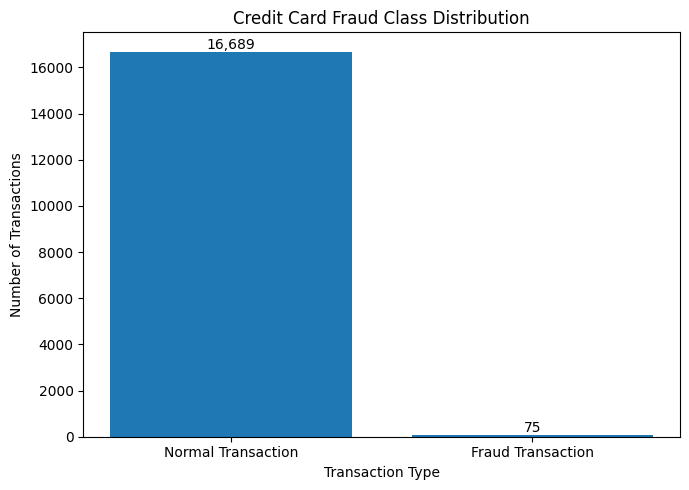

In [6]:
# =====================================================
# 4. CLASS IMBALANCE CHECK
# =====================================================

class_counts = credit_clean["Class"].value_counts().sort_index()
class_percentages = credit_clean["Class"].value_counts(normalize=True).sort_index() * 100

class_distribution = pd.DataFrame({
    "Class": ["Normal Transaction", "Fraud Transaction"],
    "Count": class_counts.values,
    "Percentage": class_percentages.round(3).values
})

display(class_distribution)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_distribution["Class"],
    class_distribution["Count"]
)

plt.title("Credit Card Fraud Class Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Class Imbalance Observation

The Credit Card Fraud dataset is highly imbalanced. Normal transactions make up the vast majority of the dataset, while fraudulent transactions are very rare.

Because of this imbalance, Accuracy alone is not sufficient to evaluate the model. A model could achieve very high Accuracy simply by predicting most transactions as normal, while still missing many fraud cases.

Therefore, Precision, Recall, F1-score, ROC-AUC, and the confusion matrix are used to evaluate the Gaussian Naive Bayes model more fairly.

In [7]:
# =====================================================
# 5. FEATURE SCALING AND TRAIN-TEST SPLIT
# =====================================================

credit_scaled = credit_clean.copy()

scaler_credit = StandardScaler()

# Scale Time and Amount because they are not PCA-transformed like V1-V28
credit_scaled[["Time", "Amount"]] = scaler_credit.fit_transform(
    credit_scaled[["Time", "Amount"]]
)

X_credit = credit_scaled.drop(columns=["Class"])
y_credit = credit_scaled["Class"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit,
    y_credit,
    test_size=0.2,
    random_state=42,
    stratify=y_credit
)

print("Credit Training Shape:", X_train_c.shape)
print("Credit Testing Shape:", X_test_c.shape)

print("\nTraining Target Distribution:")
display(y_train_c.value_counts(normalize=True).round(4).to_frame("Proportion"))

print("\nTesting Target Distribution:")
display(y_test_c.value_counts(normalize=True).round(4).to_frame("Proportion"))

Credit Training Shape: (13411, 30)
Credit Testing Shape: (3353, 30)

Training Target Distribution:


,Proportion
Class,
0,0.9955
1,0.0045



Testing Target Distribution:


,Proportion
Class,
0,0.9955
1,0.0045


In [8]:
# =====================================================
# 6. TRAIN GAUSSIAN NAIVE BAYES MODEL
# =====================================================

nb_credit = GaussianNB()

nb_credit.fit(
    X_train_c,
    y_train_c
)

nb_credit_pred = nb_credit.predict(
    X_test_c
)

nb_credit_prob = nb_credit.predict_proba(
    X_test_c
)[:, 1]

print("Gaussian Naive Bayes Credit Card Classification Report:")

print(
    classification_report(
        y_test_c,
        nb_credit_pred,
        zero_division=0
    )
)

Gaussian Naive Bayes Credit Card Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3338
           1       0.17      0.93      0.29        15

    accuracy                           0.98      3353
   macro avg       0.59      0.96      0.64      3353
weighted avg       1.00      0.98      0.99      3353



In [9]:
# =====================================================
# 7. NAIVE BAYES CREDIT PERFORMANCE METRICS
# =====================================================

nb_credit_results = pd.DataFrame({
    "Dataset": ["Credit Card Fraud"],
    "Model": ["Gaussian Naive Bayes"],
    "Accuracy": [accuracy_score(y_test_c, nb_credit_pred)],
    "Precision": [precision_score(y_test_c, nb_credit_pred, zero_division=0)],
    "Recall": [recall_score(y_test_c, nb_credit_pred, zero_division=0)],
    "F1 Score": [f1_score(y_test_c, nb_credit_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test_c, nb_credit_prob)]
})

display(nb_credit_results.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Credit Card Fraud,Gaussian Naive Bayes,0.98,0.173,0.933,0.292,0.989


In [10]:
# =====================================================
# 8. TRAIN VS TEST PERFORMANCE CHECK
# =====================================================

nb_credit_train_pred = nb_credit.predict(X_train_c)

train_test_comparison = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [
        accuracy_score(y_train_c, nb_credit_train_pred),
        accuracy_score(y_test_c, nb_credit_pred)
    ],
    "Precision": [
        precision_score(y_train_c, nb_credit_train_pred, zero_division=0),
        precision_score(y_test_c, nb_credit_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_train_c, nb_credit_train_pred, zero_division=0),
        recall_score(y_test_c, nb_credit_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_train_c, nb_credit_train_pred, zero_division=0),
        f1_score(y_test_c, nb_credit_pred, zero_division=0)
    ]
})

display(train_test_comparison.round(3))

,Dataset,Accuracy,Precision,Recall,F1 Score
0,Training Data,0.98,0.170,0.883,0.286
1,Testing Data,0.98,0.173,0.933,0.292


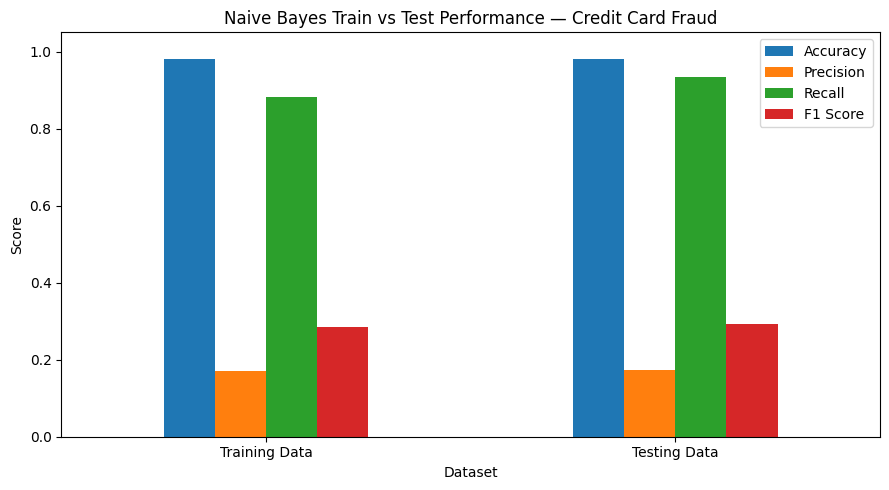

In [11]:
# =====================================================
# 9. TRAIN VS TEST PERFORMANCE VISUALISATION
# =====================================================

train_test_comparison.set_index("Dataset").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Naive Bayes Train vs Test Performance — Credit Card Fraud")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

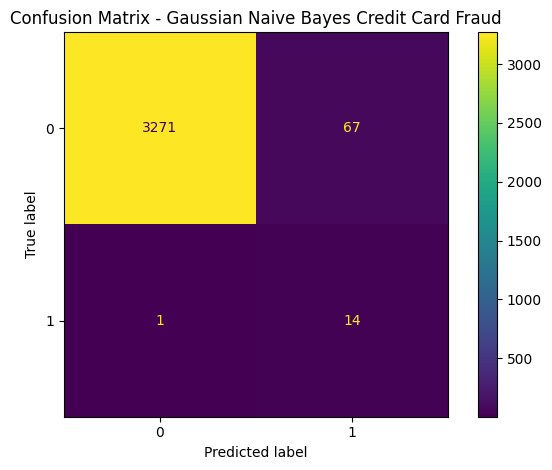

In [12]:
# =====================================================
# 10. CONFUSION MATRIX
# =====================================================

ConfusionMatrixDisplay.from_predictions(
    y_test_c,
    nb_credit_pred
)

plt.title("Confusion Matrix - Gaussian Naive Bayes Credit Card Fraud")
plt.tight_layout()
plt.show()

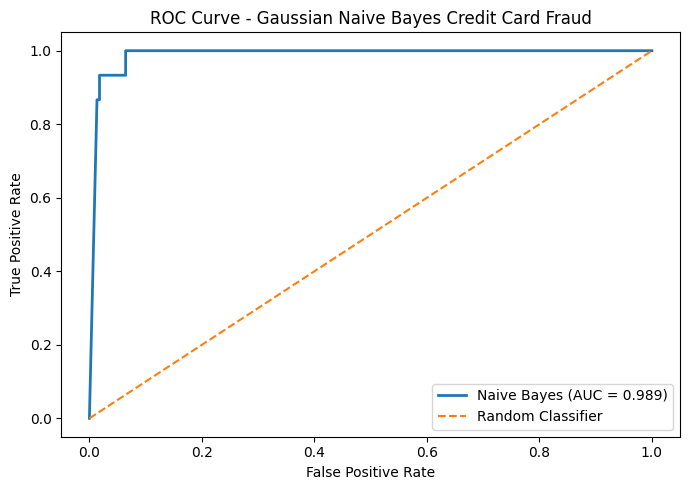

In [13]:
# =====================================================
# 11. ROC CURVE
# =====================================================

fpr, tpr, thresholds = roc_curve(
    y_test_c,
    nb_credit_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Naive Bayes (AUC = {roc_auc_score(y_test_c, nb_credit_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Gaussian Naive Bayes Credit Card Fraud")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# =====================================================
# 12. SAVE NAIVE BAYES CREDIT RESULTS
# =====================================================

nb_credit_results.to_csv(
    "../results/Naive_Bayes_credit_results.csv",
    index=False
)

print("Naive Bayes credit results saved successfully.")

from google.colab import files
files.download("../results/Naive_Bayes_credit_results.csv")

Naive Bayes credit results saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Naive Bayes Credit Card Summary

The Gaussian Naive Bayes model was applied to the Credit Card Fraud dataset to classify transactions as normal or fraudulent.

The dataset was highly imbalanced, with normal transactions being far more common than fraud transactions. Because of this, Accuracy alone was not sufficient to evaluate model performance. Precision, Recall, F1-score, ROC-AUC, and the confusion matrix were used to understand how well the model detected fraud.

The model achieved high Recall, meaning it detected the majority of actual fraud cases. However, Precision was very low, meaning the model also flagged many normal transactions as fraud. This resulted in a very low F1-score, showing that the model was not well-calibrated for this imbalanced problem.

The ROC-AUC score was strong, suggesting that the model had reasonable overall class separation ability. The ROC curve confirmed this, showing the model performed well above the random classifier baseline.

The train vs test comparison showed consistent behaviour across both sets, confirming the model was not overfitting. However, the fundamental issue was that the independence assumption of Gaussian Naive Bayes, combined with severe class imbalance, caused the decision boundary to flag too many transactions as fraudulent.

Overall, Gaussian Naive Bayes was useful as a probabilistic baseline but would require threshold adjustment or resampling techniques to be practical for real-world fraud detection.